In [1]:
import os
import cv2
import nibabel as nib
import numpy as np
import pandas as pd
from glob import glob

import torch
import torch.nn as nn
from torchvision import models

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import torch.nn.functional as F



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(device)
resnet.eval()


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor):
        output = self.model(input_tensor)
        score = output.sum()     # feature-level objective
        self.model.zero_grad()
        score.backward()

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        cam = cv2.resize(cam, (input_tensor.shape[3], input_tensor.shape[2]))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)

        return cam


In [4]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_gradcam(slice_img, cam):
    """
    slice_img : original CT slice (H, W) numpy array
    cam       : Grad-CAM heatmap (H, W) in [0,1]
    """

    # Normalize CT slice for visualization
    img = slice_img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    # Convert CAM to color heatmap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    # Overlay heatmap on CT slice
    overlay = 0.6 * np.stack([img]*3, axis=-1) + 0.4 * heatmap
    overlay = overlay / overlay.max()

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM Overlay")
    plt.show()


In [5]:
target_layer = resnet.layer4[-1]
gradcam = GradCAM(resnet, target_layer)


In [6]:
import torchvision.transforms as T

imagenet_norm = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

def preprocess_slice(slice_img):
    # Convert to float32 numpy
    img = slice_img.astype(np.float32)

    # Robust clipping
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)

    # Min-max normalize to [0,1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)

    # Convert to torch tensor WITH dtype=float32
    img = torch.from_numpy(img).float()     # 🔑 FIX IS HERE

    # Add channel & repeat to 3 channels
    img = img.unsqueeze(0).repeat(3, 1, 1)

    # ImageNet normalization
    img = imagenet_norm(img)

    return img


In [7]:
import pandas as pd
dir = r'D:\Similiar_Colorectum\14004841\case_labels_binary.csv'
df = pd.read_csv(dir)  # Assuming a CSV with 'case_id' and 'label' columns

In [8]:
case_id = df.iloc[0]["case_id"]  # or any specific case


In [9]:
from glob import glob
import nibabel as nib
import numpy as np

IMG_DIR  = r"D:\Similiar_Colorectum\14004841\images\images"
MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"

ct_path = glob(f"{IMG_DIR}/crc_{case_id}_*.nii.gz")[0]
mask_path = glob(f"{MASK_DIR}/crc_{case_id}_*.nii.gz")[0]

ct = nib.load(ct_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

tumor_slices = []
for z in range(ct.shape[2]):
    if (mask[:, :, z] > 0).any():
        tumor_slices.append(ct[:, :, z])

print("Tumor slices found:", len(tumor_slices))


Tumor slices found: 12


In [10]:
slice_img = tumor_slices[len(tumor_slices)//2]  # middle tumor slice


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


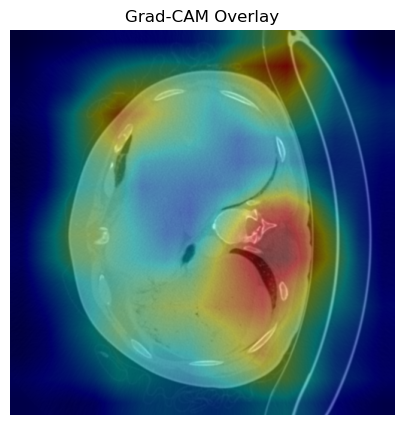

In [11]:
input_tensor = preprocess_slice(slice_img).unsqueeze(0).to(device)
cam = gradcam.generate(input_tensor)
show_gradcam(slice_img, cam)
